# **CAPSTONE PROJECT: PHASE 1**
## **Dataset creation**

This project addresses a clinically and biologically relevant problem by investigating how whole-blood DNA methylation patterns reflect biological aging and inflammaging. By quantifying epigenetic aging measures and inflammation-related methylation signatures in a large public cohort, the study provides interpretable evidence that supports aging biomarker research and contributes to real-world applications in preventive health, risk stratification, and translational biomedical analytics.

sex: This column indicates the biological sex of each participant, typically categorized as 'F' for female and 'M' for male, as observed in the pheno['sex'].value_counts() output. This variable is crucial for analyzing sex-specific differences in biological aging or epigenetic patterns.

ethnicity: This column specifies the self-reported or observed ethnic background of each participant. In your dataset, the primary categories are 'Caucasian - European' and 'Hispanic - Mexican', as seen from pheno['ethnicity'].value_counts(). This information allows for investigating how epigenetic aging might vary across different ancestral groups.

tissue: This column identifies the biological tissue type from which the DNA methylation data was derived. For your full_dataset, it consistently shows 'whole blood' for all samples, as confirmed by pheno['tissue'].value_counts(). Knowing the tissue source is vital because DNA methylation patterns can be tissue-specific, ensuring that the findings are relevant to blood-based biological processes.

## *Importing the necessary Libraries*

In [ ]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & ML
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Reproducibility
np.random.seed(42)


Justification
This project uses the GEO dataset GSE40279 accessed via the GEOparse Python package to ensure reproducible, programmatic retrieval of a well-established public DNA methylation cohort (Edgar et al., 2002). GEOparse provides a standardized way to download samples and extract phenotype metadata directly from GEO records, reducing manual handling errors and improving traceability. The dataset is widely used in epigenetic aging research, making it a credible foundation for investigating biological aging and inflammaging mechanisms (Hannum et al., 2013).

Dataset information

GSE40279 contains 656 whole-blood DNA methylation profiles measured using the Illumina HumanMethylation450K array, spanning ages 19 to 101 years, enabling robust lifespan-scale aging analysis (Hannum et al., 2013). The cohort includes balanced sex representation and two primary ethnic groups, supporting subgroup-aware evaluation. As a blood-based dataset, it is particularly relevant for studying immune-related aging processes and inflammaging. GEO provides open access to both methylation measurements and sample-level metadata, supporting transparent and reproducible research (Edgar et al., 2002).

Limitations

Because the dataset is cross-sectional, it does not capture within-individual longitudinal aging changes over time. In addition, whole-blood methylation reflects a mixture of immune cell types, so variation in cell composition may influence methylation patterns and should be considered as a potential confounder in downstream interpretation.

In [ ]:
!pip install GEOparse


## *Downloading Series Matrix File*
### GEO provides already normalized beta values

In [ ]:
import GEOparse

# Define 'gse' by attempting to fetch GEO data
try:
    gse = GEOparse.get_GEO("GSE40279", destdir=".", silent=False) # Removed silent=True for better diagnostics
    # Inspect metadata keys for ONE sample if gse was successfully defined
    sample_id = list(gse.gsms.keys())[0]
    print(f"Successfully loaded GSE40279. First sample ID: {sample_id}")
    print("Metadata keys for first sample:")
    print(gse.gsms[sample_id].metadata.keys())
except Exception as e:
    print(f"Error fetching or processing GEO data: {e}")
    gse = None # Ensure gse is explicitly None if an error occurs

14-Feb-2026 07:37:52 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
14-Feb-2026 07:37:52 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE40nnn/GSE40279/soft/GSE40279_family.soft.gz to ./GSE40279_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE40nnn/GSE40279/soft/GSE40279_family.soft.gz to ./GSE40279_family.soft.gz
100%|██████████| 2.64G/2.64G [03:07<00:00, 15.1MB/s]
14-Feb-2026 07:41:01 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
14-Feb-2026 07:41:01 DEBUG downloader - Moving /tmp/tmp46wiiate to /content/GSE40279_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp46wiiate to /content/GSE40279_family.soft.gz
14-Feb-2026 07:41:02 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE40nnn/GSE40279/soft/GSE40279_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE40nnn/GSE4027

Successfully loaded GSE40279. First sample ID: GSM989827
Metadata keys for first sample:
dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count'])


## *Inspecting GEO Sample Phenotype Metadata from characteristics_ch1*

In [ ]:
sample_id = list(gse.gsms.keys())[0]
gse.gsms[sample_id].metadata['characteristics_ch1']

['age (y): 67',
 'source: UCSD',
 'plate: 1',
 'gender: F',
 'ethnicity: Caucasian - European',
 'tissue: whole blood']

### *This code selects the first sample ID from the GEO dataset (gse.gsms) and prints the contents of its characteristics_ch1 field. The output shows that key phenotype variables are stored as a list of descriptive labels, including age, gender, ethnicity, and tissue type, along with technical metadata such as source and plate. This step confirms where the project’s phenotype variables are located and guides accurate extraction of the required columns for downstream analysis.*

## *Function to Extract Key Phenotype Variables (Age, Sex, Ethnicity, Tissue) from GEO Sample Metadata*

In [ ]:
def extract_characteristics(gsm):
    age = None
    sex = None
    ethnicity = None
    tissue = None

    for item in gsm.metadata.get('characteristics_ch1', []):
        item_l = item.lower()

        # Age extraction (handles: age (y): 67)
        if item_l.startswith('age'):
            age_str = item.split(':')[-1].strip()
            age = ''.join(c for c in age_str if c.isdigit())

        # Sex / gender extraction
        elif item_l.startswith('gender') or item_l.startswith('sex'):
            sex = item.split(':')[-1].strip().upper()

        # Ethnicity extraction
        elif item_l.startswith('ethnicity'):
            ethnicity = item.split(':')[-1].strip()

        # Tissue extraction
        elif item_l.startswith('tissue'):
            tissue = item.split(':')[-1].strip()

    return age, sex, ethnicity, tissue


#### *This function reads the characteristics_ch1 metadata field for a given GEO sample (gsm) and extracts four biologically relevant variables: age, sex, ethnicity, and tissue. Since GEO stores these values as text strings (e.g., "age (y): 67"), the function standardizes them by isolating the value after the colon (:), converting age to numeric digits, converting sex to uppercase (F/M), and keeping ethnicity and tissue as clean categorical text. The output is returned as a structured tuple (age, sex, ethnicity, tissue), enabling reliable creation of a clean phenotype table for downstream analysis.*

## *Creating a Clean Phenotype Table from GEO Sample Metadata*

In [ ]:
records = []

for gsm_name, gsm in gse.gsms.items():
    age, sex, ethnicity, tissue = extract_characteristics(gsm)

    records.append({
        'sample_id': gsm_name,
        'age': age,
        'sex': sex,
        'ethnicity': ethnicity,
        'tissue': tissue
    })

pheno = pd.DataFrame(records).set_index('sample_id')

# Convert age to numeric
pheno['age'] = pd.to_numeric(pheno['age'], errors='coerce')

pheno.head()


,age,sex,ethnicity,tissue
sample_id,,,,
GSM989827,67,F,Caucasian - European,whole blood
GSM989828,89,F,Caucasian - European,whole blood
GSM989829,66,F,Caucasian - European,whole blood
GSM989830,64,F,Caucasian - European,whole blood
GSM989831,62,F,Caucasian - European,whole blood


#### *This code iterates through all samples in the GEO dataset (gse.gsms), applies the extract_characteristics() function to extract age, sex, ethnicity, and tissue, and stores the results in a structured list called records. The list is then converted into a pandas DataFrame (pheno) with sample_id set as the index to preserve the GEO sample identifiers. Finally, the age column is converted into a numeric format to support statistical analysis. The output (pheno.head()) confirms that the phenotype dataset has been successfully constructed in a clean, analysis-ready form.*

## *Phenotype Dataset Sanity Checks and Summary Statistics*

In [ ]:
print("Shape:", pheno.shape)

print("\nMissing values per column:")
print(pheno.isna().sum())

print("\nAge summary:")
print(pheno['age'].describe())

print("\nSex distribution:")
print(pheno['sex'].value_counts())

print("\nEthnicity distribution:")
print(pheno['ethnicity'].value_counts().head())

print("\nTissue distribution:")
print(pheno['tissue'].value_counts())


Shape: (656, 4)

Missing values per column:
age          0
sex          0
ethnicity    0
tissue       0
dtype: int64

Age summary:
count    656.000000
mean      64.035061
std       14.736681
min       19.000000
25%       54.000000
50%       65.000000
75%       75.000000
max      101.000000
Name: age, dtype: float64

Sex distribution:
sex
F    338
M    318
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
Caucasian - European    426
Hispanic - Mexican      230
Name: count, dtype: int64

Tissue distribution:
tissue
whole blood    656
Name: count, dtype: int64


#### *The phenotype dataset contains 656 samples and 4 key variables (age, sex, ethnicity, tissue), confirming successful metadata extraction. All fields have zero missing values, indicating the dataset is complete and suitable for analysis. The age distribution spans 19 to 101 years (mean ≈ 64.0, median 65), providing a strong range for aging-related investigation. Sex distribution is well balanced (338 females, 318 males), and the cohort includes two primary ethnic groups (Caucasian–European and Hispanic–Mexican). Tissue information confirms that all samples are whole blood (656/656), ensuring biological consistency for downstream methylation analysis.*

## **Visualization Setup for Exploratory Data Analysis (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (8, 6)


## **Histogram of Participant Age Distribution**

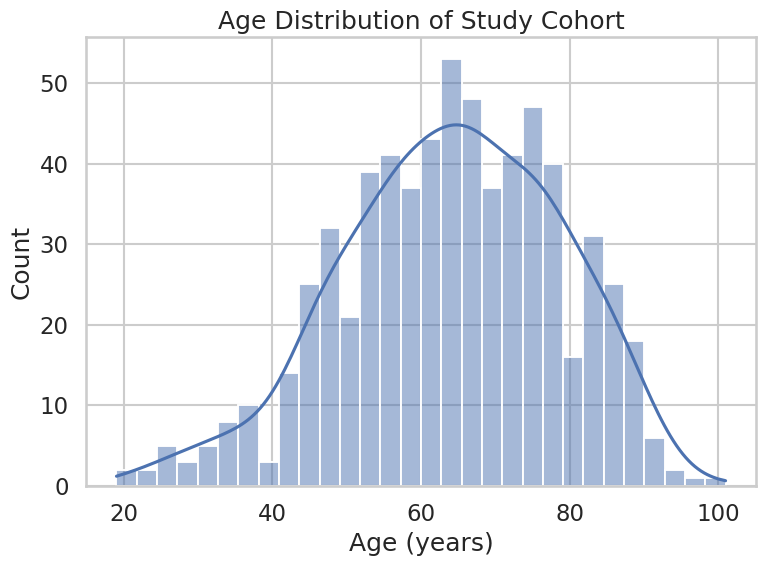

In [ ]:
plt.figure()
sns.histplot(pheno['age'], bins=30, kde=True)
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.title("Age Distribution of Study Cohort")
plt.tight_layout()
plt.show()


#### *This plot visualizes the age distribution of the study cohort using a histogram with 30 bins and an overlaid kernel density curve (KDE). The figure shows that the dataset includes a broad age range, with the highest concentration of participants in the middle-to-older adult age groups, which is appropriate for studying biological aging patterns. The smooth KDE curve helps highlight the overall shape of the age distribution, confirming that the cohort provides sufficient variability across ages for downstream epigenetic aging analysis.*

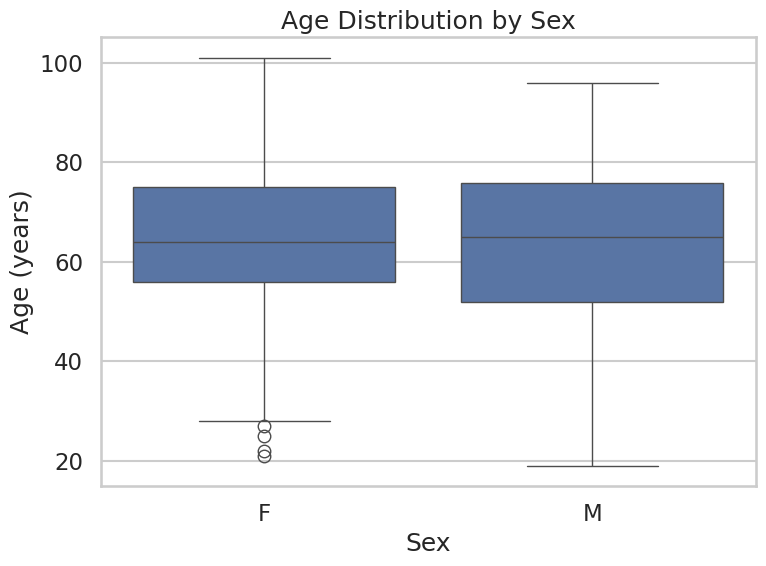

In [ ]:
plt.figure()
sns.boxplot(data=pheno, x='sex', y='age')
plt.xlabel("Sex")
plt.ylabel("Age (years)")
plt.title("Age Distribution by Sex")
plt.tight_layout()
plt.show()


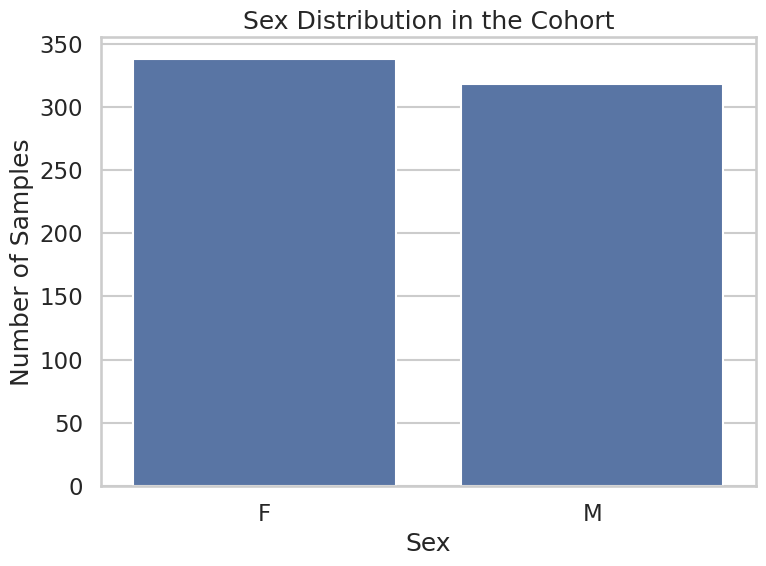

In [ ]:
plt.figure()
sns.countplot(data=pheno, x='sex')
plt.xlabel("Sex")
plt.ylabel("Number of Samples")
plt.title("Sex Distribution in the Cohort")
plt.tight_layout()
plt.show()


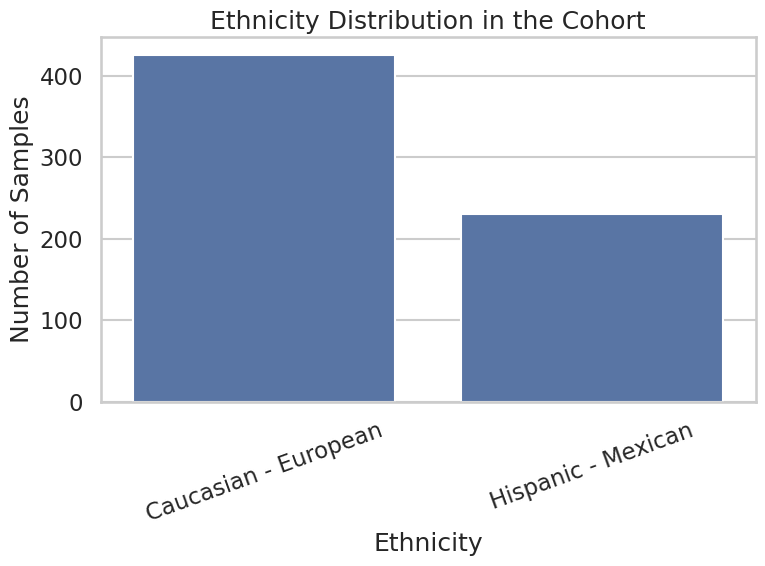

In [ ]:
plt.figure()
sns.countplot(
    data=pheno,
    x='ethnicity',
    order=pheno['ethnicity'].value_counts().index
)
plt.xlabel("Ethnicity")
plt.ylabel("Number of Samples")
plt.title("Ethnicity Distribution in the Cohort")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


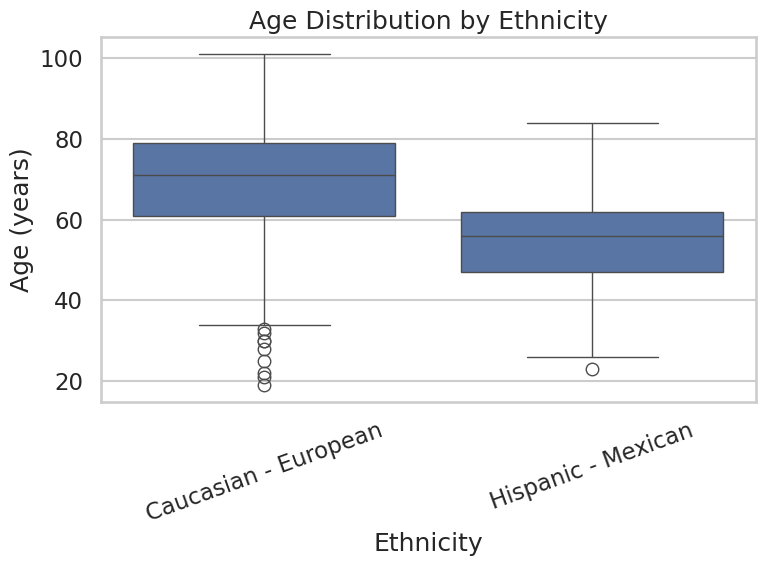

In [ ]:
plt.figure()
sns.boxplot(data=pheno, x='ethnicity', y='age')
plt.xlabel("Ethnicity")
plt.ylabel("Age (years)")
plt.title("Age Distribution by Ethnicity")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


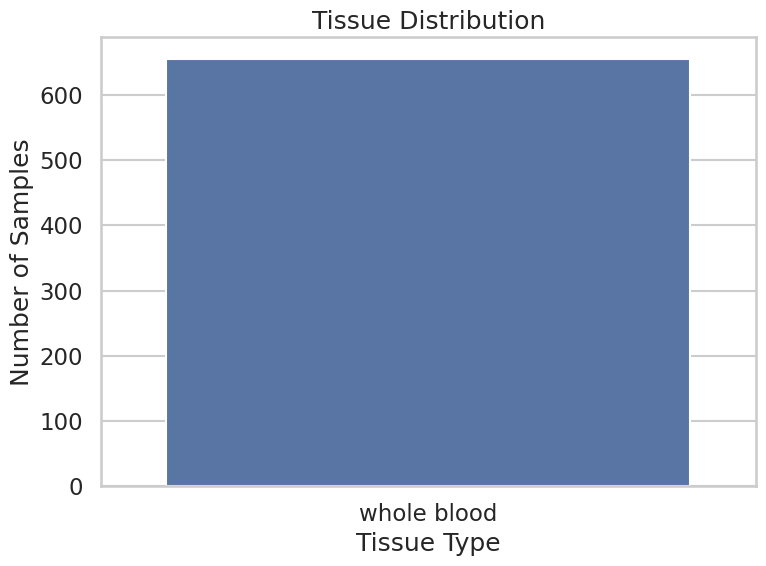

In [ ]:
plt.figure()
sns.countplot(data=pheno, x='tissue')
plt.xlabel("Tissue Type")
plt.ylabel("Number of Samples")
plt.title("Tissue Distribution")
plt.tight_layout()
plt.show()


In [ ]:
!git clone https://github.com/yiluyucheng/dnaMethyAge.git



fatal: destination path 'dnaMethyAge' already exists and is not an empty directory.


In [ ]:
!ls dnaMethyAge


data  DESCRIPTION  man	NAMESPACE  R  README.md  test_res


In [ ]:
!find dnaMethyAge -iname "*horvath*"


dnaMethyAge/data/HorvathS2018.rda
dnaMethyAge/data/HorvathS2013.rda
dnaMethyAge/R/preprocessHorvathS2013.R


In [ ]:
%%bash
apt-get update -qq
apt-get install -y r-base


Reading package lists...
Building dependency tree...
Reading state information...
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 48 not upgraded.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
%%bash
Rscript -e "
load('dnaMethyAge/data/HorvathS2013.rda');

obj_name <- ls()[1];
clock_obj <- get(obj_name);

# Inspect structure (for transparency)
print(names(clock_obj));
print(head(clock_obj$coefs));

# Extract CpG probes correctly
cpgs <- unique(clock_obj$coefs$Probe);

write.csv(
  data.frame(CpG = cpgs),
  'horvathS2013_353_cpgs.csv',
  row.names = FALSE
);

cat('Exported', length(cpgs), 'CpGs\n');
"


[1] "Probe"       "Coefficient"
       Probe Coefficient
1  Intercept 0.695507258
2 cg00075967 0.129336610
3 cg00374717 0.005017857
4 cg00864867 1.599764050
5 cg00945507 0.056852418
6 cg01027739 0.102862854
Exported 2 CpGs


In [ ]:
import pandas as pd

horvath_df = pd.read_csv("horvathS2013_353_cpgs.csv")
# Correct the column name from 'CpG' to 'CpG.Probe'
horvath_cpgs = set(horvath_df['CpG.Probe'])

print("Number of HorvathS2013 CpGs:", len(horvath_cpgs))
horvath_df.head()

Number of HorvathS2013 CpGs: 354


,CpG.Probe,CpG.Coefficient
0,Intercept,0.695507
1,cg00075967,0.129337
2,cg00374717,0.005018
3,cg00864867,1.599764
4,cg00945507,0.056852


In [ ]:
# Remove intercept if present
horvath_cpgs = set(horvath_df['CpG.Probe'])
horvath_cpgs.discard("Intercept")

print("CpGs after removing Intercept:", len(horvath_cpgs))


CpGs after removing Intercept: 353


In [ ]:
from collections import defaultdict

beta_filtered = defaultdict(dict)

for gsm_name, gsm in gse.gsms.items():
    table = gsm.table[['ID_REF', 'VALUE']]
    table = table[table['ID_REF'].isin(horvath_cpgs)]

    for _, row in table.iterrows():
        beta_filtered[row['ID_REF']][gsm_name] = row['VALUE']


In [ ]:
beta_df = pd.DataFrame(beta_filtered).T
beta_df = beta_df[pheno.index]

X_meth = beta_df.T
print(X_meth.shape)


(656, 353)


In [ ]:
print("Missing values:", X_meth.isna().sum().sum())
print("Beta range:", X_meth.min().min(), X_meth.max().max())
print("Sample alignment:", X_meth.index.equals(pheno.index))


Missing values: 0
Beta range: 0.0 0.9989952
Sample alignment: True


In [ ]:
X_meth.to_csv("X_meth_horvathS2013_353cpgs.csv")
pheno.to_csv("phenotype_table_gse40279.csv")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os, shutil

project_path = "/content/drive/MyDrive/epigenetic-inflammaging-capstone"
os.makedirs(project_path, exist_ok=True)

shutil.copy("X_meth_horvathS2013_353cpgs.csv", project_path)
shutil.copy("phenotype_table_gse40279.csv", project_path)

print("Files saved to Drive folder:", project_path)
!ls -lh "$project_path"


Files saved to Drive folder: /content/drive/MyDrive/epigenetic-inflammaging-capstone
total 9.2M
-rw------- 1 root root 2.3M Feb 14 08:35 full_dataset.csv
-rw------- 1 root root 2.4M Feb 14 08:17 full_dataset_with_pheno.csv
-rw------- 1 root root 2.4M Feb 14 08:01 full_dataset_with_predictions.csv
-rw------- 1 root root  31K Feb 14 08:37 phenotype_table_gse40279.csv
-rw------- 1 root root 2.3M Feb 14 08:37 X_meth_horvathS2013_353cpgs.csv


In [ ]:
!du -h X_meth_horvathS2013_353cpgs.csv


2.3M	X_meth_horvathS2013_353cpgs.csv


In [ ]:
full_dataset = pd.concat([X_meth, pheno], axis=1)
print("Shape of the combined dataset:", full_dataset.shape)
full_dataset.head()

Shape of the combined dataset: (656, 357)


,cg19945840,cg13319175,cg21211748,cg19420968,cg14992253,cg26372517,cg19046959,cg07388493,cg19044674,cg23786576,...,cg19167673,cg11932564,cg26453588,cg26394940,cg13269407,cg17285325,age,sex,ethnicity,tissue
GSM989827,0.444277,0.861711,0.101486,0.896825,0.160218,0.307110,0.082667,0.496128,0.098169,0.065347,...,0.139496,0.019724,0.467923,0.179889,0.183261,0.058724,67,F,Caucasian - European,whole blood
GSM989828,0.452810,0.859130,0.084701,0.873240,0.185472,0.234680,0.071071,0.431277,0.119546,0.064218,...,0.132948,0.020527,0.408547,0.038715,0.095460,0.045616,89,F,Caucasian - European,whole blood
GSM989829,0.448331,0.899934,0.108838,0.887437,0.169848,0.379860,0.088703,0.428772,0.096857,0.072193,...,0.122528,0.028049,0.546796,0.066730,0.091018,0.067457,66,F,Caucasian - European,whole blood
GSM989830,0.395542,0.888273,0.095387,0.884306,0.246246,0.328234,0.073749,0.463588,0.092399,0.060480,...,0.133658,0.016729,0.455221,0.082762,0.094618,0.017405,64,F,Caucasian - European,whole blood
GSM989831,0.414505,0.871372,0.089478,0.854875,0.191453,0.377763,0.090162,0.440927,0.114674,0.068286,...,0.124878,0.014422,0.549047,0.130325,0.122995,0.044303,62,F,Caucasian - European,whole blood


In [ ]:
display(full_dataset.head())

,cg19945840,cg13319175,cg21211748,cg19420968,cg14992253,cg26372517,cg19046959,cg07388493,cg19044674,cg23786576,...,cg19167673,cg11932564,cg26453588,cg26394940,cg13269407,cg17285325,age,sex,ethnicity,tissue
GSM989827,0.444277,0.861711,0.101486,0.896825,0.160218,0.307110,0.082667,0.496128,0.098169,0.065347,...,0.139496,0.019724,0.467923,0.179889,0.183261,0.058724,67,F,Caucasian - European,whole blood
GSM989828,0.452810,0.859130,0.084701,0.873240,0.185472,0.234680,0.071071,0.431277,0.119546,0.064218,...,0.132948,0.020527,0.408547,0.038715,0.095460,0.045616,89,F,Caucasian - European,whole blood
GSM989829,0.448331,0.899934,0.108838,0.887437,0.169848,0.379860,0.088703,0.428772,0.096857,0.072193,...,0.122528,0.028049,0.546796,0.066730,0.091018,0.067457,66,F,Caucasian - European,whole blood
GSM989830,0.395542,0.888273,0.095387,0.884306,0.246246,0.328234,0.073749,0.463588,0.092399,0.060480,...,0.133658,0.016729,0.455221,0.082762,0.094618,0.017405,64,F,Caucasian - European,whole blood
GSM989831,0.414505,0.871372,0.089478,0.854875,0.191453,0.377763,0.090162,0.440927,0.114674,0.068286,...,0.124878,0.014422,0.549047,0.130325,0.122995,0.044303,62,F,Caucasian - European,whole blood


In [ ]:
full_dataset.to_csv("full_dataset.csv", index=True)
print("full_dataset.csv saved locally.")

full_dataset.csv saved locally.


#### Copying the file in the drive

In [ ]:
import shutil

project_path = "/content/drive/MyDrive/epigenetic-inflammaging-capstone"
shutil.copy("full_dataset.csv", project_path)

print(f"'full_dataset_.csv' copied to Drive folder: {project_path}")

'full_dataset_.csv' copied to Drive folder: /content/drive/MyDrive/epigenetic-inflammaging-capstone


In [ ]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/epigenetic-inflammaging-capstone"
file_path = os.path.join(project_path, "full_dataset.csv")

try:
    full_dataset = pd.read_csv(file_path, index_col=0)
    print("Successfully loaded full_dataset from Google Drive.")
    print("First 5 rows of the loaded dataset:")
    display(full_dataset.head())
    print("\nShape of the loaded dataset:", full_dataset.shape)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it exists in your Google Drive.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Successfully loaded full_dataset from Google Drive.
First 5 rows of the loaded dataset:


,cg19945840,cg13319175,cg21211748,cg19420968,cg14992253,cg26372517,cg19046959,cg07388493,cg19044674,cg23786576,...,cg19167673,cg11932564,cg26453588,cg26394940,cg13269407,cg17285325,age,sex,ethnicity,tissue
GSM989827,0.444277,0.861711,0.101486,0.896825,0.160218,0.307110,0.082667,0.496128,0.098169,0.065347,...,0.139496,0.019724,0.467923,0.179889,0.183261,0.058724,67,F,Caucasian - European,whole blood
GSM989828,0.452810,0.859130,0.084701,0.873240,0.185472,0.234680,0.071071,0.431277,0.119546,0.064218,...,0.132948,0.020527,0.408547,0.038715,0.095460,0.045616,89,F,Caucasian - European,whole blood
GSM989829,0.448331,0.899934,0.108838,0.887437,0.169848,0.379860,0.088703,0.428772,0.096857,0.072193,...,0.122528,0.028049,0.546796,0.066730,0.091018,0.067457,66,F,Caucasian - European,whole blood
GSM989830,0.395542,0.888273,0.095387,0.884306,0.246246,0.328234,0.073749,0.463588,0.092399,0.060480,...,0.133658,0.016729,0.455221,0.082762,0.094618,0.017405,64,F,Caucasian - European,whole blood
GSM989831,0.414505,0.871372,0.089478,0.854875,0.191453,0.377763,0.090162,0.440927,0.114674,0.068286,...,0.124878,0.014422,0.549047,0.130325,0.122995,0.044303,62,F,Caucasian - European,whole blood



Shape of the loaded dataset: (656, 357)


### Final Data Check
Check for missing values, duplicate rows, and review data types in the `full_dataset` DataFrame to understand its completeness and quality, then summarize the findings to identify any data cleaning needs.

## Checking for Missing Values

Identifying and counting any missing values in the `full_dataset` DataFrame to understand the completeness of the data.


In [ ]:
print("Missing values per column in full_dataset:")
print(full_dataset.isnull().sum())

Missing values per column in full_dataset:
cg19945840    0
cg13319175    0
cg21211748    0
cg19420968    0
cg14992253    0
             ..
cg17285325    0
age           0
sex           0
ethnicity     0
tissue        0
Length: 357, dtype: int64


### *No missing values hence no imputation or removal strategies are needed.*

## Checking for Duplicate Rows

Identifing and counting any duplicate rows in the `full_dataset` DataFrame to ensure data uniqueness.

In [ ]:
print("Number of duplicate rows in full_dataset:")
print(full_dataset.duplicated().sum())

Number of duplicate rows in full_dataset:
0


## Reviewing Data Types
Examining the data types of each column in the `full_dataset` DataFrame to ensure they are appropriate for their content and for downstream analysis.

In [ ]:
print(full_dataset.dtypes)

cg19945840    float64
cg13319175    float64
cg21211748    float64
cg19420968    float64
cg14992253    float64
               ...   
cg17285325    float64
age             int64
sex            object
ethnicity      object
tissue         object
Length: 357, dtype: object


## Summary of Data Quality Checks

Based on the performed checks:

*   **Missing Values**: There are no missing values across any column in the `full_dataset` DataFrame.
*   **Duplicate Rows**: No duplicate rows were identified in the `full_dataset` DataFrame, ensuring data uniqueness.
*   **Data Types**: The data types for all columns are appropriate. CpG site beta values are `float64`, `age` is `int64`, and categorical variables (`sex`, `ethnicity`, `tissue`) are `object`.

**Conclusion**: The `full_dataset` DataFrame is complete, unique, and has correctly assigned data types. No immediate data cleaning is required, and the dataset is ready for further exploratory data analysis and model training.